# Pruning search results with Jev: near-duplicates and false positives

Hybrid search fills the first page with whatever scores highest, so it shows near-identical items side by side and lets in items that share the query's words without matching it. MMR spreads the page out, but it only measures distance between embeddings: it can't tell a real duplicate from two different items that happen to sit close together, and it never asks whether an item matches the query.

This recipe puts Jev, TypeSafe's decision model, after retrieval:

**hybrid search (dense + BM25, RRF) → Qdrant MMR over the top 50 → Jev reads the top 20 → keep the first 10 that survive**

Jev gets one request per query: the query and the 20 results in rank order. For each result it answers two yes/no questions: is it relevant to the query, and is it a near-duplicate of a result ranked above it. The answers are probabilities, so thresholds are set afterwards and one request serves any threshold. If fewer than 10 results survive, the page is backfilled with the dropped ones, most relevant first by Jev's answer.

The notebook measures it on **WANDS** (Wayfair's product-search benchmark: 42,994 products, 480 queries, graded Exact / Partial / Irrelevant judgments) and answers four questions:

1. Does pruning keep nDCG@10?
2. Does it remove the Irrelevant results hybrid search surfaces?
3. Does Jev's duplicate question diversify the page better than cosine-similarity dedup at the same pruning budget?
4. Does it drift toward unjudged results, where nDCG can't see what it did?

## What the pilot established

Before building this, a 5-query pilot ($0.0026, 15 requests) tested whether Jev can answer questions about "result 7" in a numbered list of 20 in one request:

| check | result |
|---|---|
| same 20 results, order reversed: does each result keep its relevance answer? | correlation 0.98, mean change 0.05 |
| exact copy of result 3 planted at position 12: does `dup_12` fire? | 0.95 to 0.99 on all 5 queries; other duplicate answers in those requests average 0.23 |
| mean relevance answer by WANDS label | Exact 0.93, Partial 0.55 |
| cost | $0.00017 per request (20 results of 300 characters, 39 questions) |

So Jev's answers follow the result, not its position, and one request per query is enough.

The pilot also showed a limit of the data. WANDS's judgments were collected on another system's results, so hybrid search's first page is mostly judged but rarely Irrelevant: over all 480 queries its top 10 is 35% Exact, 42% Partial, **4.4% Irrelevant** (102 queries have at least one) and **18.6% unjudged**. The Irrelevant count is a real but small signal, and the unjudged share is large enough that nDCG alone can't tell whether pruning helped or just swapped unjudged results for judged ones. Both are reported below.

## Which classifier runs

- **With `OPENROUTER_API_KEY` set** (in the environment or in `.env` at the repo root), Jev (`typesafe/jev-1.13`) judges every list through OpenRouter's System One endpoint. The notebook judges a small pilot batch first, extrapolates the cost from the responses, and stops if the estimate exceeds `JEVQU_MAX_USD` (default $1). Answers are cached in `.jev_cache/`, so reruns cost nothing.
- **Without a key**, a **simulated** Jev stands in so the notebook runs offline: its relevance answer is the WANDS label plus noise, and its duplicate answer comes from product-name word overlap. Numbers from the simulated run show that the pipeline works end to end. They say nothing about Jev's quality.

In [1]:
import json, os, random, sys, time, warnings, zlib
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")                    # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Local mode is not recommended")         # in-memory Qdrant, 43k points

import numpy as np
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jevqu").is_dir())
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.jev import Jev
from jevqu.metrics import paired_bootstrap
from recipes import wands
from recipes.prune.prune import KEEP, SNIP, TOP, judge, prune, questions

SEED = 0
DIVERSITY = (0.25, 0.5, 0.75)  # Qdrant MMR diversity: 0 ranks by relevance only, 1 by diversity only
MID = 0.5                      # the MMR setting whose output Jev prunes
CANDIDATES = 50                # MMR re-ranks the hybrid top 50
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "1"))  # judging stops before spending more than this
WORKERS = 8                    # parallel Jev requests (stays under Jev's ~1,200 requests a minute)
PILOT = 10                     # queries judged first to price the full run
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "SIMULATED (no OPENROUTER_API_KEY)")

classifier: Jev (typesafe/jev-1.13) on OpenRouter


## 1. Load WANDS and index every product

`recipes/wands.py` downloads WANDS on first use and indexes all 42,994 products with dense `BAAI/bge-small-en-v1.5` and sparse BM25 vectors (FastEmbed), the same setup as `notebooks/jevqu_wands_demo.ipynb` without its 10k-product sample. Dense vectors are cached in `data/wands/`; the first run embeds for about 8 minutes on a laptop CPU, later runs take a few minutes for BM25.

Each product's text is its name plus the start of its description. `product_class` is used only to measure diversity: Jev never sees it.

In [2]:
products, queries, labels = wands.load("product"), wands.load("query"), wands.load("label")
G = wands.grades(labels)
t0 = time.time()
client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
dense, bm25 = wands.build_index(client, products)
V = np.load(wands.DATA / f"dense_full_{len(products)}.npy")  # row i is product i; for the cosine-dedup baseline
V /= np.linalg.norm(V, axis=1, keepdims=True)
qtexts = [q["query"] for q in queries]
qd = [d.tolist() for d in dense.embed(qtexts)]
qs = [wands.sparse_vec(s) for s in bm25.embed(qtexts)]
print(f"{len(products):,} products indexed, {len(queries)} queries, {len(labels):,} judgments, {time.time() - t0:.0f}s")

42,994 products indexed, 480 queries, 233,448 judgments, 11s


## 2. Candidate lists

For every query: the hybrid top 20, and the MMR top 20 at three diversity settings plus diversity 0. MMR is greedy, so its top 10 is the first half of its top 20.

Qdrant's MMR scores relevance as dense similarity to the query, not as the RRF score, so even at low diversity the MMR order is a dense-only order of the hybrid candidates. Diversity 0 is that re-ranking alone, with no diversity: it separates what MMR costs by dropping BM25 from the ranking from what it costs by diversifying.

In [3]:
def search(i, mmr=None):
    return [h.id for h in wands.hybrid(client, qd[i], qs[i], limit=TOP, mmr=mmr)]

t0 = time.time()
path = wands.DATA / f"prune_cands_top{TOP}_cand{CANDIDATES}_div{'-'.join(map(str, DIVERSITY))}.json"
if path.exists():  # search is deterministic, so the lists depend only on these settings
    cands = json.loads(path.read_text())
else:
    cands = {"hybrid": [search(i) for i in range(len(queries))]}
    for d in (0.0, *DIVERSITY):
        cands[f"MMR {d}"] = [search(i, models.Mmr(diversity=d, candidates_limit=CANDIDATES)) for i in range(len(queries))]
    path.write_text(json.dumps(cands))
grade = lambda i, p: G.get(queries[i]["query_id"], {}).get(p)
mix = Counter(grade(i, p) for i, c in enumerate(cands["hybrid"]) for p in c[:KEEP])
n = sum(mix.values())
print(f"searched in {time.time() - t0:.0f}s. Hybrid top 10: Exact {mix[2] / n:.1%}, Partial {mix[1] / n:.1%}, "
      f"Irrelevant {mix[0] / n:.1%}, unjudged {mix[None] / n:.1%}")

searched in 0s. Hybrid top 10: Exact 35.1%, Partial 41.8%, Irrelevant 4.4%, unjudged 18.6%


## 3. The Jev request

One request per list. The state is the query and the 20 results, numbered in rank order and cut to 300 characters each; the questions are a relevance question for every result and a duplicate question for every result after the first (39 in all). The wording is generic, with nothing specific to shopping, so the same request works on any collection.

In [4]:
state = {"query": qtexts[0], "results": [{"result": n, "text": wands.text(products[p])[:70] + "..."}
                                       for n, p in enumerate(cands["hybrid"][0][:3], 1)]}
print(json.dumps(state, indent=1))
for qid, q in questions(3).items():
    print(f"{qid:6} {q['instructions']}\n       yes: {q['criteria']['true']}\n       no:  {q['criteria']['false']}")

{
 "query": "salon chair",
 "results": [
  {
   "result": 1,
   "text": "massage chair. features heavy duty steel frame . premium chrome round ..."
  },
  {
   "result": 2,
   "text": "fashion casual work beauty salon task chair. ..."
  },
  {
   "result": 3,
   "text": "mercer41 hair salon chair hydraulic styling chair ( rose gold ). merce..."
  }
 ]
}
rel_1  Is result 1 relevant to the query?
       yes: Someone searching for the query would accept result 1 as an answer
       no:  Result 1 is not what the query asks for
rel_2  Is result 2 relevant to the query?
       yes: Someone searching for the query would accept result 2 as an answer
       no:  Result 2 is not what the query asks for
dup_2  Is result 2 a near-duplicate of a result ranked above it (results 1 to 1)?
       yes: Result 2 is the same item as a result ranked above it, or a trivial variant of that item
       no:  Result 2 is a different item from every result ranked above it
rel_3  Is result 3 relevant to the query

## 4. Judge the lists

Jev judges two lists per query: the hybrid top 20, and the top 20 of MMR at diversity 0.5. Pruning the hybrid list directly tests whether Jev's duplicate question makes MMR unnecessary.

In [5]:
GRADE_P = {2: 0.93, 1: 0.55, 0: 0.10, None: 0.30}  # simulated mean relevance answer per WANDS grade:
                                                   # Exact and Partial from the pilot, Irrelevant and unjudged assumed

class SimulatedJev:
    # SIMULATED, not Jev. Same ask() contract, so the rest of the notebook runs the real code path.
    # Relevance: the WANDS label's mean above plus noise. Duplicate: high when the product name shares
    # 60%+ of its words with a result ranked above it. Noise is seeded per (query, product).
    model = "simulated"

    def __init__(self, noise=0.15):
        self.noise, self.usage = noise, []
        self.pid = {wands.text(p)[:SNIP]: int(p["product_id"]) for p in products}
        self.qid = {q["query"]: q["query_id"] for q in queries}

    def _p(self, mean, *key):
        rng = random.Random(zlib.crc32("|".join(map(str, key)).encode()))
        return min(1.0, max(0.0, rng.gauss(mean, self.noise)))

    def ask(self, state, questions):
        g = G.get(self.qid[state["query"]], {})
        pids = [self.pid[r["text"]] for r in state["results"]]
        words = [set(products[p]["product_name"].split()) for p in pids]
        out = {}
        for k in questions:
            kind, i = k.split("_")[0], int(k.split("_")[1]) - 1
            if kind == "rel":
                mean = GRADE_P[g.get(pids[i])]
            else:
                overlap = max(len(words[i] & w) / (len(words[i] | w) or 1) for w in words[:i])
                mean = 0.85 if overlap >= 0.6 else 0.15
            out[k] = {"type": "noul", "noul": self._p(mean, state["query"], kind, pids[i])}
        return out

jev = Jev() if USE_JEV else SimulatedJev()
JUDGED = ["hybrid", f"MMR {MID}"]
jobs = [(name, i) for i in range(len(queries)) for name in JUDGED]
judge_job = lambda job: judge(jev, qtexts[job[1]], [wands.text(products[p]) for p in cands[job[0]][job[1]]])

with ThreadPoolExecutor(WORKERS) as ex:
    if USE_JEV:  # price a pilot batch before judging everything
        list(ex.map(judge_job, jobs[:PILOT * len(JUDGED)]))
        estimate = sum(jev.usage) / max(1, len(jev.usage)) * len(jobs)
        print(f"pilot: about ${estimate:.2f} to judge all {len(jobs)} lists (uncached requests cost ${np.mean(jev.usage or [0]):.5f} each)")
        assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD}: raise it to continue"
    t0 = time.time()
    answers = dict(zip(jobs, ex.map(judge_job, jobs)))
print(f"judged {len(answers)} lists in {time.time() - t0:.0f}s")
if USE_JEV:
    print(f"spent ${sum(jev.usage):.4f} on {len(jev.usage)} uncached Jev requests")

pilot: about $0.00 to judge all 960 lists (uncached requests cost $0.00000 each)
judged 960 lists in 0s
spent $0.0000 on 0 uncached Jev requests


### Do the relevance answers track the labels?

Over every judged result in the hybrid top 20: the mean relevance answer per WANDS label, and the AUC of the answer for telling Exact or Partial results from Irrelevant ones (0.5 is chance).

In [6]:
pairs = [(grade(i, p), answers[("hybrid", i)][0][r]) for i in range(len(queries)) for r, p in enumerate(cands["hybrid"][i])]
by = {g: [p for x, p in pairs if x == g] for g in (2, 1, 0, None)}
pos, neg = np.array(by[2] + by[1]), np.array(by[0])
auc = np.mean([(pos > b).mean() + 0.5 * (pos == b).mean() for b in neg])
rows = ["| label | results | mean relevance answer |", "|---|---|---|"]
rows += [f"| {name} | {len(by[g]):,} | {np.mean(by[g]):.2f} |" for g, name in [(2, "Exact"), (1, "Partial"), (0, "Irrelevant"), (None, "unjudged")]]
display(Markdown("\n".join(rows) + f"\n\nAUC, Exact or Partial vs Irrelevant: **{auc:.3f}**"))

| label | results | mean relevance answer |
|---|---|---|
| Exact | 3,044 | 0.86 |
| Partial | 4,105 | 0.42 |
| Irrelevant | 458 | 0.21 |
| unjudged | 1,993 | 0.33 |

AUC, Exact or Partial vs Irrelevant: **0.845**

## 5. Baselines and thresholds

The queries are split in half at random. Thresholds are chosen on the first half and every result below is reported on the second.

- **Relevance threshold:** the cutoff on Jev's relevance answer that gives the best nDCG@10 on the tuning half, with the duplicate question on.
- **Duplicate threshold:** 0.5, fixed. nDCG can't tune it: WANDS judges each colour or size variant on its own, so removing a duplicate of an Exact result removes an Exact result and nDCG always prefers keeping duplicates.
- **Cosine dedup** (the cheap baseline): walk the list in rank order and drop any result whose dense-vector cosine to a result already kept is at least τ. τ is set so that, on the tuning half, cosine dedup drops as many results as Jev's duplicate question flags, so the two are compared at the same pruning budget.

In [7]:
rng = random.Random(SEED)
order = list(range(len(queries)))
rng.shuffle(order)
TUNE, TEST = sorted(order[:len(order) // 2]), sorted(order[len(order) // 2:])
gq = lambda i: G.get(queries[i]["query_id"], {})
mean_ndcg = lambda pages, qset: np.mean([wands.ndcg(pages[i], gq(i)) for i in qset])

def cosine_dedup(ids, tau, keep=KEEP):
    kept, dropped = [], []
    for p in ids:
        (dropped if kept and (V[kept] @ V[p]).max() >= tau else kept).append(p)
    return (kept + dropped)[:keep], len(dropped)

def jev_pages(name, rel_min, dup_max):
    out = {i: prune(ids, *answers[(name, i)], rel_min, dup_max) for i, ids in enumerate(cands[name])}
    return {i: p for i, (p, _) in out.items()}, {i: b for i, (_, b) in out.items()}

REL_GRID = [round(x, 2) for x in np.arange(0, 0.95, 0.05)]
DUP_MAX, OFF = 0.5, 1.01
rel_min = {name: float(max(REL_GRID, key=lambda r: mean_ndcg(jev_pages(name, r, DUP_MAX)[0], TUNE))) for name in JUDGED}

def match_tau(name):  # τ whose drop count on TUNE is closest to the number of results Jev flags as duplicates
    target = sum(sum(d >= DUP_MAX for d in answers[(name, i)][1]) for i in TUNE)
    return min(np.arange(0.80, 1.0, 0.0025), key=lambda t: abs(sum(cosine_dedup(cands[name][i], t)[1] for i in TUNE) - target))

tau = {name: float(match_tau(name)) for name in JUDGED}
print("relevance threshold (tuned):", rel_min, "| cosine tau (matched budget):", {k: round(v, 4) for k, v in tau.items()})

relevance threshold (tuned): {'hybrid': 0.9, 'MMR 0.5': 0.9} | cosine tau (matched budget): {'hybrid': 0.9275, 'MMR 0.5': 0.9025}


### Re-ranker baselines

When the tuned relevance cutoff sits near the top of its range and most pages are backfilled, the Jev prune is mostly re-ordering the hybrid top 20 by Jev's relevance answer. The fair comparison is then a re-ranker, so three more pipelines read the same hybrid top 20 with the same 300-character text Jev sees:

- **hybrid + Jev rerank**: the top 20 sorted by Jev's relevance answer, no cutoff and no duplicate question. It reuses the answers above, so it costs nothing.
- **hybrid + bge-reranker-base rerank** and **hybrid + ms-marco-MiniLM-L-6-v2 rerank**: local cross-encoders through FastEmbed, the standard way to re-order a first page. bge-reranker-base is the strongest one FastEmbed ships; MiniLM-L-6 is the small, fast one.

In [8]:
from fastembed.rerank.cross_encoder import TextCrossEncoder

RERANKERS = ["BAAI/bge-reranker-base", "Xenova/ms-marco-MiniLM-L-6-v2"]
ce = {}
for m in RERANKERS:
    t0, path = time.time(), wands.DATA / f"rerank_{m.split('/')[-1]}_top{TOP}_snip{SNIP}.json"
    if path.exists():  # scores depend only on the hybrid lists, which are deterministic
        ce[m] = {int(i): s for i, s in json.loads(path.read_text()).items()}
    else:
        enc = TextCrossEncoder(m)
        ce[m] = {i: [float(x) for x in enc.rerank(qtexts[i], [wands.text(products[p])[:SNIP] for p in c], batch_size=TOP)]
                 for i, c in enumerate(cands["hybrid"])}
        path.write_text(json.dumps(ce[m]))
    print(f"{m}: {sum(map(len, ce[m].values())):,} query-result pairs scored in {time.time() - t0:.0f}s")

BAAI/bge-reranker-base: 9,600 query-result pairs scored in 0s
Xenova/ms-marco-MiniLM-L-6-v2: 9,600 query-result pairs scored in 0s


## 6. Results on the held-out half

- **nDCG@10**: graded (Exact 2, Partial 1, Irrelevant and unjudged 0), with the change against hybrid search and its 95% paired-bootstrap interval.
- **Irrelevant in top 10**: summed over the held-out queries. Lower is better.
- **Exact lost / Partial lost**: results from hybrid search's top 10 with that label that the pipeline dropped from its top 10.
- **classes in top 10**: distinct `product_class` values on the page, a proxy for diversity.
- **judged in top 10**: share of the page with any WANDS label. A drop means the pipeline moved toward results nDCG can't score.
- **backfilled**: share of queries where fewer than 10 results survived Jev.

In [9]:
H = f"MMR {MID}"
pages = {"hybrid search": {i: c[:KEEP] for i, c in enumerate(cands["hybrid"])}}
pages["MMR, diversity 0 (dense re-rank only)"] = {i: c[:KEEP] for i, c in enumerate(cands["MMR 0.0"])}
pages |= {f"MMR, diversity {d}": {i: c[:KEEP] for i, c in enumerate(cands[f"MMR {d}"])} for d in DIVERSITY}
pages[f"MMR {MID} + cosine dedup"] = {i: cosine_dedup(c, tau[H])[0] for i, c in enumerate(cands[H])}
pages["hybrid + cosine dedup"] = {i: cosine_dedup(c, tau["hybrid"])[0] for i, c in enumerate(cands["hybrid"])}
backfill = {}
for label, name, r, dm in [(f"MMR {MID} + Jev prune", H, rel_min[H], DUP_MAX),
                           ("hybrid + Jev prune", "hybrid", rel_min["hybrid"], DUP_MAX),
                           ("hybrid + Jev relevance only", "hybrid", rel_min["hybrid"], OFF),
                           ("hybrid + Jev duplicates only", "hybrid", 0.0, DUP_MAX)]:
    pages[label], backfill[label] = jev_pages(name, r, dm)

def by_score(c, s):  # the list re-ordered by a score, highest first (ties keep rank order)
    return [c[r] for r in sorted(range(len(c)), key=lambda r: -s[r])][:KEEP]

pages["hybrid + Jev rerank"] = {i: by_score(c, answers[("hybrid", i)][0]) for i, c in enumerate(cands["hybrid"])}
for m in RERANKERS:
    pages[f"hybrid + {m.split('/')[-1]} rerank"] = {i: by_score(c, ce[m][i]) for i, c in enumerate(cands["hybrid"])}

def report(pages, qset):
    base = [wands.ndcg(pages["hybrid search"][i], gq(i)) for i in qset]
    rows = ["| pipeline | nDCG@10 | change (95% CI) | Irrelevant in top 10 | Exact lost | Partial lost | classes in top 10 | judged in top 10 | backfilled |",
            "|---|---|---|---|---|---|---|---|---|"]
    for name, pg in pages.items():
        nd = [wands.ndcg(pg[i], gq(i)) for i in qset]
        d, lo, hi = paired_bootstrap(base, nd)
        lost = lambda g: sum(p not in pg[i] for i in qset for p in pages["hybrid search"][i] if grade(i, p) == g)
        irr = sum(grade(i, p) == 0 for i in qset for p in pg[i])
        classes = np.mean([len({products[p]["product_class"] for p in pg[i] if products[p]["product_class"]}) for i in qset])
        judged = np.mean([grade(i, p) is not None for i in qset for p in pg[i]])
        bf = f"{np.mean([backfill[name][i] for i in qset]):.0%}" if name in backfill else ""
        rows.append(f"| {name} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {irr} | {lost(2)} | {lost(1)} | {classes:.2f} | {judged:.1%} | {bf} |")
    return "\n".join(rows)

display(Markdown(f"**{'Jev' if USE_JEV else 'SIMULATED Jev'}**, {len(TEST)} held-out queries\n\n" + report(pages, TEST)))

**Jev**, 240 held-out queries

| pipeline | nDCG@10 | change (95% CI) | Irrelevant in top 10 | Exact lost | Partial lost | classes in top 10 | judged in top 10 | backfilled |
|---|---|---|---|---|---|---|---|---|
| hybrid search | 0.6831 | +0.0000 (+0.0000 to +0.0000) | 102 | 0 | 0 | 3.17 | 81.3% |  |
| MMR, diversity 0 (dense re-rank only) | 0.6349 | -0.0482 (-0.0676 to -0.0275) | 95 | 385 | 370 | 2.72 | 79.9% |  |
| MMR, diversity 0.25 | 0.6179 | -0.0652 (-0.0840 to -0.0453) | 118 | 412 | 434 | 3.62 | 78.5% |  |
| MMR, diversity 0.5 | 0.5606 | -0.1225 (-0.1438 to -0.1019) | 139 | 552 | 642 | 4.74 | 72.6% |  |
| MMR, diversity 0.75 | 0.5158 | -0.1673 (-0.1928 to -0.1400) | 155 | 686 | 738 | 5.24 | 67.7% |  |
| MMR 0.5 + cosine dedup | 0.5606 | -0.1225 (-0.1438 to -0.1019) | 139 | 556 | 644 | 4.74 | 72.6% |  |
| hybrid + cosine dedup | 0.6742 | -0.0089 (-0.0154 to -0.0023) | 104 | 123 | 136 | 3.38 | 80.7% |  |
| MMR 0.5 + Jev prune | 0.7174 | +0.0342 (+0.0148 to +0.0561) | 67 | 485 | 621 | 3.16 | 83.2% | 82% |
| hybrid + Jev prune | 0.7653 | +0.0822 (+0.0660 to +0.0980) | 40 | 226 | 417 | 2.44 | 86.5% | 83% |
| hybrid + Jev relevance only | 0.7649 | +0.0818 (+0.0651 to +0.0975) | 40 | 186 | 417 | 2.44 | 86.5% | 75% |
| hybrid + Jev duplicates only | 0.6728 | -0.0103 (-0.0166 to -0.0041) | 103 | 129 | 109 | 3.37 | 80.9% | 1% |
| hybrid + Jev rerank | 0.7689 | +0.0858 (+0.0687 to +0.1018) | 38 | 273 | 421 | 2.41 | 86.5% |  |
| hybrid + bge-reranker-base rerank | 0.7297 | +0.0466 (+0.0305 to +0.0630) | 83 | 311 | 385 | 2.84 | 84.7% |  |
| hybrid + ms-marco-MiniLM-L-6-v2 rerank | 0.7469 | +0.0638 (+0.0480 to +0.0800) | 83 | 314 | 435 | 2.73 | 85.4% |  |

### The diversity–nDCG trade-off

Jev's duplicate threshold and cosine dedup's τ both trade nDCG for a more varied page. The sweep below runs both on the hybrid top 20 (relevance question off) over the held-out half. It is a diagnostic, not a tuning step: the settings above were fixed on the tuning half. At the same number of classes on the page, the method with the higher nDCG is removing the right results.

In [10]:
rows = ["| method | setting | nDCG@10 | classes in top 10 | Exact lost |", "|---|---|---|---|---|"]
hyb = pages["hybrid search"]
def row(method, setting, pg):
    lost = sum(p not in pg[i] for i in TEST for p in hyb[i] if grade(i, p) == 2)
    classes = np.mean([len({products[p]["product_class"] for p in pg[i] if products[p]["product_class"]}) for i in TEST])
    return f"| {method} | {setting} | {mean_ndcg(pg, TEST):.4f} | {classes:.2f} | {lost} |"
rows += [row("Jev duplicate question", f"dup < {dm}", jev_pages("hybrid", 0.0, dm)[0]) for dm in (0.9, 0.7, 0.5, 0.3, 0.2)]
rows += [row("cosine dedup", f"τ = {t}", {i: cosine_dedup(c, t)[0] for i, c in enumerate(cands["hybrid"])})
         for t in (0.98, 0.95, 0.92, 0.9, 0.88)]
display(Markdown("\n".join(rows)))

| method | setting | nDCG@10 | classes in top 10 | Exact lost |
|---|---|---|---|---|
| Jev duplicate question | dup < 0.9 | 0.6806 | 3.20 | 16 |
| Jev duplicate question | dup < 0.7 | 0.6754 | 3.26 | 72 |
| Jev duplicate question | dup < 0.5 | 0.6728 | 3.37 | 129 |
| Jev duplicate question | dup < 0.3 | 0.6637 | 3.50 | 207 |
| Jev duplicate question | dup < 0.2 | 0.6567 | 3.61 | 255 |
| cosine dedup | τ = 0.98 | 0.6831 | 3.23 | 23 |
| cosine dedup | τ = 0.95 | 0.6799 | 3.33 | 64 |
| cosine dedup | τ = 0.92 | 0.6718 | 3.42 | 137 |
| cosine dedup | τ = 0.9 | 0.6658 | 3.53 | 179 |
| cosine dedup | τ = 0.88 | 0.6617 | 3.62 | 207 |

### Diversity checks

Two questions the tables above leave open, both answered from the Jev answers already collected:

1. **Is there a setting with more variety than hybrid search and no loss of nDCG?** The relevance cutoff above was tuned for nDCG alone and landed at the top of its range, which strips out what MMR adds. The sweep below lowers the cutoff on the MMR 0.5 list (duplicate question at 0.5) and, for comparison, on the hybrid list. ✓ marks a row that beats hybrid search on both nDCG@10 and classes in the top 10.
2. **Does the duplicate question make the page less repetitive within a class?** Class count can't see seven colours of one chair. *Near-duplicate pairs* counts pairs of results on the page whose dense-vector cosine is at least 0.95, a measure that doesn't depend on Jev's answers.

Both are on the held-out half. Class count is a proxy: an off-topic result adds a class too, so more classes is not automatically a better page.

In [11]:
NEAR = 0.95
pairs = lambda pg: np.mean([int((np.triu(V[pg[i]] @ V[pg[i]].T, 1) >= NEAR).sum()) for i in TEST])
n_classes = lambda pg: np.mean([len({products[p]["product_class"] for p in pg[i] if products[p]["product_class"]}) for i in TEST])
base_nd, base_cl = mean_ndcg(pages["hybrid search"], TEST), n_classes(pages["hybrid search"])

rows = ["| pipeline | relevance cutoff | nDCG@10 | classes in top 10 | near-duplicate pairs in top 10 | beats hybrid on both |",
        "|---|---|---|---|---|---|"]
def add(name, cutoff, pg):
    nd, cl = mean_ndcg(pg, TEST), n_classes(pg)
    rows.append(f"| {name} | {cutoff} | {nd:.4f} | {cl:.2f} | {pairs(pg):.2f} | {'✓' if nd >= base_nd and cl > base_cl else ''} |")

add("hybrid search", "", pages["hybrid search"])
for d in (0.0, *DIVERSITY):
    add(f"MMR {d}", "", {i: c[:KEEP] for i, c in enumerate(cands[f"MMR {d}"])})
for name in (H, "hybrid"):
    for r in (0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9):
        add(f"{name} + Jev prune", r, jev_pages(name, r, DUP_MAX)[0])
for name in ("hybrid + Jev rerank", *(f"hybrid + {m.split('/')[-1]} rerank" for m in RERANKERS), "hybrid + cosine dedup"):
    add(name, "", pages[name])
display(Markdown("\n".join(rows)))

| pipeline | relevance cutoff | nDCG@10 | classes in top 10 | near-duplicate pairs in top 10 | beats hybrid on both |
|---|---|---|---|---|---|
| hybrid search |  | 0.6831 | 3.17 | 1.27 |  |
| MMR 0.0 |  | 0.6349 | 2.72 | 1.94 |  |
| MMR 0.25 |  | 0.6179 | 3.62 | 0.48 |  |
| MMR 0.5 |  | 0.5606 | 4.74 | 0.00 |  |
| MMR 0.75 |  | 0.5158 | 5.24 | 0.00 |  |
| MMR 0.5 + Jev prune | 0.0 | 0.5602 | 4.75 | 0.00 |  |
| MMR 0.5 + Jev prune | 0.3 | 0.6655 | 3.54 | 0.03 |  |
| MMR 0.5 + Jev prune | 0.5 | 0.6883 | 3.39 | 0.04 | ✓ |
| MMR 0.5 + Jev prune | 0.6 | 0.6922 | 3.35 | 0.04 | ✓ |
| MMR 0.5 + Jev prune | 0.7 | 0.6996 | 3.31 | 0.04 | ✓ |
| MMR 0.5 + Jev prune | 0.8 | 0.7069 | 3.23 | 0.04 | ✓ |
| MMR 0.5 + Jev prune | 0.9 | 0.7174 | 3.16 | 0.04 |  |
| hybrid + Jev prune | 0.0 | 0.6728 | 3.37 | 0.50 |  |
| hybrid + Jev prune | 0.3 | 0.7296 | 2.76 | 0.80 |  |
| hybrid + Jev prune | 0.5 | 0.7435 | 2.67 | 0.85 |  |
| hybrid + Jev prune | 0.6 | 0.7475 | 2.64 | 0.89 |  |
| hybrid + Jev prune | 0.7 | 0.7540 | 2.60 | 0.92 |  |
| hybrid + Jev prune | 0.8 | 0.7581 | 2.53 | 0.98 |  |
| hybrid + Jev prune | 0.9 | 0.7653 | 2.44 | 1.12 |  |
| hybrid + Jev rerank |  | 0.7689 | 2.41 | 1.25 |  |
| hybrid + bge-reranker-base rerank |  | 0.7297 | 2.84 | 1.54 |  |
| hybrid + ms-marco-MiniLM-L-6-v2 rerank |  | 0.7469 | 2.73 | 1.25 |  |
| hybrid + cosine dedup |  | 0.6742 | 3.38 | 0.11 |  |

### Paired tests

The comparisons the findings rest on, each as a paired bootstrap over the held-out queries. The variety recipe's cutoff is tuned on the tuning half: the lowest cutoff on the MMR list whose nDCG@10 there is at least hybrid search's (a lower cutoff keeps more of MMR's variety).

In [12]:
tune_base = mean_ndcg(pages["hybrid search"], TUNE)
r_var = min(r for r in REL_GRID if mean_ndcg(jev_pages(H, r, DUP_MAX)[0], TUNE) >= tune_base)
pages[f"{H} + Jev prune, cutoff {r_var}"] = jev_pages(H, r_var, DUP_MAX)[0]
nd = lambda name: [wands.ndcg(pages[name][i], gq(i)) for i in TEST]
rows = ["| comparison | nDCG@10 difference (95% CI) |", "|---|---|"]
for a, b in [*(("hybrid + Jev rerank", f"hybrid + {m.split('/')[-1]} rerank") for m in RERANKERS),
             (f"{H} + Jev prune, cutoff {r_var}", "hybrid search")]:
    d, lo, hi = paired_bootstrap(nd(b), nd(a))
    rows.append(f"| {a} − {b} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) |")
v = pages[f"{H} + Jev prune, cutoff {r_var}"]
rows += ["", f"Variety recipe on the held-out half (cutoff {r_var}, tuned): {n_classes(v):.2f} classes and {pairs(v):.2f} near-duplicate pairs "
         f"in the top 10, against {base_cl:.2f} and {pairs(pages['hybrid search']):.2f} for hybrid search."]
display(Markdown("\n".join(rows)))

| comparison | nDCG@10 difference (95% CI) |
|---|---|
| hybrid + Jev rerank − hybrid + bge-reranker-base rerank | +0.0392 (+0.0226 to +0.0545) |
| hybrid + Jev rerank − hybrid + ms-marco-MiniLM-L-6-v2 rerank | +0.0220 (+0.0076 to +0.0385) |
| MMR 0.5 + Jev prune, cutoff 0.55 − hybrid search | +0.0070 (-0.0118 to +0.0263) |

Variety recipe on the held-out half (cutoff 0.55, tuned): 3.39 classes and 0.04 near-duplicate pairs in the top 10, against 3.17 and 1.27 for hybrid search.

## 7. Before and after

Four held-out queries: the two where Jev's prune removed the most Irrelevant results from the hybrid top 10, and the two where it flagged the most duplicates. Each table is the hybrid top 20 with Jev's answers and what the prune did: kept (with its new position), dropped as irrelevant, dropped as a duplicate, or backfilled.

In [13]:
P = "hybrid + Jev prune"
NAME = {2: "Exact", 1: "Partial", 0: "Irrelevant", None: "unjudged"}
irr_removed = lambda i: sum(grade(i, p) == 0 for p in hyb[i]) - sum(grade(i, p) == 0 for p in pages[P][i])
dups = lambda i: sum(d >= DUP_MAX for d in answers[("hybrid", i)][1])
picks = sorted(TEST, key=irr_removed, reverse=True)[:2]
picks += [i for i in sorted(TEST, key=dups, reverse=True) if i not in picks][:2]
for i in picks:
    rel, dup = answers[("hybrid", i)]
    rows = [f'**"{qtexts[i]}"**: {irr_removed(i)} Irrelevant removed from the top 10, {dups(i)} duplicates flagged', "",
            "| # | label | relevance | duplicate | prune | product |", "|---|---|---|---|---|---|"]
    for r, p in enumerate(cands["hybrid"][i]):
        survived = rel[r] >= rel_min["hybrid"] and dup[r] < DUP_MAX
        at = pages[P][i].index(p) + 1 if p in pages[P][i] else None
        what = (f"kept, #{at}" if survived and at else "kept (below 10)" if survived else
                f"backfilled, #{at}" if at else "dropped: irrelevant" if rel[r] < rel_min["hybrid"] else "dropped: duplicate")
        rows.append(f"| {r + 1} | {NAME[grade(i, p)]} | {rel[r]:.2f} | {dup[r]:.2f} | {what} | {products[p]['product_name'][:60]} |")
    display(Markdown("\n".join(rows)))

**"capricorn chest"**: 6 Irrelevant removed from the top 10, 3 duplicates flagged

| # | label | relevance | duplicate | prune | product |
|---|---|---|---|---|---|
| 1 | Exact | 0.93 | 0.00 | kept, #1 | capricorn 5 drawer chest |
| 2 | Irrelevant | 0.09 | 0.04 | dropped: irrelevant | capricorn zodiac sign throw pillow |
| 3 | Irrelevant | 0.07 | 0.35 | dropped: irrelevant | capricorn zodiac sign lumbar pillow |
| 4 | Exact | 0.46 | 0.12 | backfilled, #5 | capricorn 7 drawer dresser |
| 5 | Irrelevant | 0.24 | 0.19 | dropped: irrelevant | capricorn rustic dresser mirror |
| 6 | Irrelevant | 0.23 | 0.09 | dropped: irrelevant | capricorn platform configurable bedroom set |
| 7 | Exact | 0.50 | 0.83 | backfilled, #2 | capricorn 7 drawer dresser with mirror |
| 8 | Irrelevant | 0.09 | 0.67 | dropped: irrelevant | capricorn zodiac sign illustration pillow cover |
| 9 | Irrelevant | 0.07 | 0.46 | dropped: irrelevant | capricorn zodiac sign indoor/outdoor throw pillow |
| 10 | Partial | 0.25 | 0.08 | dropped: irrelevant | fincher chest |
| 11 | Irrelevant | 0.09 | 0.63 | dropped: irrelevant | dulin capricorn zodiac sign throw pillow |
| 12 | Partial | 0.36 | 0.08 | backfilled, #10 | millenium accent chest |
| 13 | Partial | 0.34 | 0.12 | dropped: irrelevant | tall chest |
| 14 | Partial | 0.34 | 0.11 | dropped: irrelevant | bawtry accent chest |
| 15 | Partial | 0.39 | 0.10 | backfilled, #8 | kisner 5 drawer accent chest |
| 16 | Partial | 0.38 | 0.11 | backfilled, #9 | orono chest |
| 17 | Partial | 0.42 | 0.12 | backfilled, #7 | guilford 5 drawer chest |
| 18 | Partial | 0.50 | 0.19 | backfilled, #3 | klaudia 5 drawer chest |
| 19 | Partial | 0.48 | 0.07 | backfilled, #4 | multiva chest |
| 20 | Partial | 0.46 | 0.10 | backfilled, #6 | amadora chest |

**"46 inch closet door"**: 5 Irrelevant removed from the top 10, 7 duplicates flagged

| # | label | relevance | duplicate | prune | product |
|---|---|---|---|---|---|
| 1 | Irrelevant | 0.24 | 0.00 | backfilled, #9 | bi-fold closet door snugger |
| 2 | Irrelevant | 0.03 | 0.03 | dropped: irrelevant | 46 bottle and 149 can single zone freestanding wine & bevera |
| 3 | Partial | 0.62 | 0.06 | backfilled, #1 | frosted glass sliding closet door |
| 4 | Irrelevant | 0.05 | 0.03 | dropped: irrelevant | ledesma over the door wall hook |
| 5 | Irrelevant | 0.23 | 0.79 | dropped: irrelevant | bi-fold 2 closet door snugger |
| 6 | Irrelevant | 0.06 | 0.04 | dropped: irrelevant | holiday storage 46.75 '' h x 23.5 '' w x 0.5 '' d moisture r |
| 7 | Irrelevant | 0.22 | 0.83 | dropped: irrelevant | bi-fold closet 2-door snugger |
| 8 | unjudged | 0.06 | 0.04 | dropped: irrelevant | dial lock safe |
| 9 | Irrelevant | 0.21 | 0.66 | dropped: irrelevant | bi-fold closet 4-door snugger |
| 10 | unjudged | 0.18 | 0.05 | dropped: irrelevant | terrace antique brass passage hall/closet door knob with uni |
| 11 | Partial | 0.54 | 0.09 | backfilled, #2 | plush wood planum sliding closet door |
| 12 | Partial | 0.54 | 0.12 | backfilled, #3 | louvered wood finish athanas sliding closet doors |
| 13 | Partial | 0.51 | 0.20 | backfilled, #6 | paneled wood lucia sliding closet door |
| 14 | Irrelevant | 0.24 | 0.53 | backfilled, #10 | bi-fold closet door top mount door snugger |
| 15 | Irrelevant | 0.21 | 0.15 | dropped: irrelevant | bi-fold closet door pivot rod |
| 16 | Partial | 0.52 | 0.22 | backfilled, #5 | felicia glass sliding closet doors |
| 17 | Partial | 0.46 | 0.95 | backfilled, #8 | paneled wood planum sliding closet door |
| 18 | Partial | 0.47 | 0.98 | backfilled, #7 | paneled wood planum sliding closet door |
| 19 | Irrelevant | 0.21 | 0.08 | dropped: irrelevant | 45 '' w closet system |
| 20 | Partial | 0.53 | 0.94 | backfilled, #4 | felicia glass sliding closet door |

**"shoe bench entryway"**: 0 Irrelevant removed from the top 10, 12 duplicates flagged

| # | label | relevance | duplicate | prune | product |
|---|---|---|---|---|---|
| 1 | Exact | 0.97 | 0.00 | kept, #1 | entryway 6 pair shoe storage bench |
| 2 | Exact | 0.96 | 0.71 | backfilled, #8 | entryway origanizer shoe bench |
| 3 | Exact | 0.96 | 0.93 | backfilled, #9 | simple entryway shoe bench |
| 4 | Exact | 0.96 | 0.26 | kept, #2 | entry 8 pair shoe storage bench |
| 5 | Exact | 0.89 | 0.14 | dropped: irrelevant | entryway bench , industrial shoe bench for living room , rus |
| 6 | Exact | 0.96 | 0.90 | backfilled, #10 | simple entryway 10 pair shoe storage bench |
| 7 | Exact | 0.96 | 0.37 | kept, #3 | 3-tier shoe bench for entryway shoe storage organizer rack w |
| 8 | Partial | 0.76 | 0.52 | dropped: irrelevant | shoe storage bench |
| 9 | Exact | 0.96 | 0.53 | dropped: duplicate | 2 tier entryway metal soft seat 6 pair shoe storage bench |
| 10 | Exact | 0.91 | 0.31 | kept, #4 | wood shoe bench |
| 11 | Partial | 0.52 | 0.31 | dropped: irrelevant | bamboo entryway 8 pair shoe rack |
| 12 | Partial | 0.76 | 0.74 | dropped: irrelevant | 6 pair shoe bench |
| 13 | Exact | 0.97 | 0.55 | backfilled, #7 | entryway shoe storage bench |
| 14 | Exact | 0.94 | 0.24 | kept, #5 | tillotson shoe storage bench |
| 15 | Exact | 0.96 | 0.62 | dropped: duplicate | entryway padded 10 pair shoe storage bench |
| 16 | Exact | 0.94 | 0.50 | dropped: duplicate | metal shoe storage bench |
| 17 | Exact | 0.84 | 0.53 | dropped: irrelevant | shoe bench |
| 18 | Exact | 0.94 | 0.67 | dropped: duplicate | 10 pair shoe storage bench |
| 19 | Exact | 0.96 | 0.60 | dropped: duplicate | entryway wooden 8 pair shoe storage bench |
| 20 | Exact | 0.94 | 0.14 | kept, #6 | shreffler shoe storage bench |

**"accent chairs living room"**: 0 Irrelevant removed from the top 10, 11 duplicates flagged

| # | label | relevance | duplicate | prune | product |
|---|---|---|---|---|---|
| 1 | Exact | 0.95 | 0.00 | kept, #1 | accent chair living room chair bedroom chair home chair with |
| 2 | Exact | 0.94 | 0.10 | kept, #2 | modern wing back accent chair roll arm living room cushion w |
| 3 | Exact | 0.95 | 0.89 | backfilled, #8 | modern soft velvet material ergonomics accent chair living r |
| 4 | Exact | 0.95 | 0.90 | backfilled, #9 | modern soft velvet material red ergonomics accent chair livi |
| 5 | Exact | 0.96 | 0.19 | kept, #3 | modern shell-shaped backrest accent chair for living room be |
| 6 | Exact | 0.89 | 0.93 | dropped: irrelevant | modern soft velvet material ergonomics accent chair living r |
| 7 | unjudged | 0.91 | 0.10 | kept, #4 | 31 '' wide tufted polyester armchair |
| 8 | Exact | 0.94 | 0.87 | dropped: duplicate | modern new soft velvet material ergonomics accent chair livi |
| 9 | Exact | 0.93 | 0.94 | dropped: duplicate | modern new soft velvet material ergonomics accent chair livi |
| 10 | Exact | 0.94 | 0.93 | dropped: duplicate | modern soft velvet material green ergonomics accent chair li |
| 11 | Exact | 0.93 | 0.97 | dropped: duplicate | modern soft velvet material green ergonomics accent chair li |
| 12 | unjudged | 0.93 | 0.12 | kept, #5 | ervey 40 '' wide tufted armchair |
| 13 | Partial | 0.95 | 0.75 | backfilled, #10 | solid color velvet accent chair modern soft upholstered chai |
| 14 | unjudged | 0.92 | 0.09 | kept, #6 | schunemunk 28 '' wide polyester armchair |
| 15 | Exact | 0.95 | 0.69 | dropped: duplicate | modern soft velvet material brown ergonomics accent chair li |
| 16 | Exact | 0.93 | 0.92 | dropped: duplicate | modern soft velvet material brown ergonomics accent chair li |
| 17 | Exact | 0.89 | 0.09 | dropped: irrelevant | driskill 51 '' wide polyester armchair |
| 18 | unjudged | 0.85 | 0.08 | dropped: irrelevant | malibu 39 '' wide tufted chesterfield chair |
| 19 | Exact | 0.89 | 0.69 | dropped: irrelevant | modern soft velvet material ergonomics tufted armless chair  |
| 20 | Exact | 0.94 | 0.44 | kept, #7 | accent chair living room/bed room , modern leisure chair pin |

## 8. Which Jev method?

The same Jev answers can be used five ways. Each is swept over its one setting:

- **Jev rerank**: sort the hybrid top 20 by Jev's relevance answer minus α × its duplicate answer. α = 0 is the plain rerank; a larger α pushes near-duplicates down the page instead of removing them.
- **Jev prune**: keep results whose relevance is at least the cutoff and whose duplicate answer is below 0.5, in hybrid order; backfill by relevance (section 5).
- **Jev MMR**: MMR over the hybrid top 20 with Jev's relevance answer as the relevance term and dense cosine as the redundancy term: at each step pick the result with the highest (1 − diversity) × relevance − diversity × (its highest cosine to a result already picked). This is Qdrant's MMR with Jev's answer in place of dense similarity to the query, the term that costs Qdrant's MMR its nDCG.
- **Qdrant MMR 0.5 + Jev prune** and **Qdrant MMR 0.5 + Jev rerank**: Jev on Qdrant MMR's top 20.

Accuracy is nDCG@10 and the Irrelevant count; diversity is near-duplicate pairs on the page (repetition, lower is better) and classes on the page (spread). Each method's setting is chosen on the tuning half twice, once for the best nDCG@10 and once for the fewest near-duplicate pairs among settings whose nDCG@10 is at least hybrid search's, and reported on the held-out half.

In [14]:
def metrics(pg, qset):
    return {"ndcg": mean_ndcg(pg, qset), "irr": sum(grade(i, p) == 0 for i in qset for p in pg[i]),
            "classes": np.mean([len({products[p]["product_class"] for p in pg[i] if products[p]["product_class"]}) for i in qset]),
            "pairs": np.mean([int((np.triu(V[pg[i]] @ V[pg[i]].T, 1) >= NEAR).sum()) for i in qset])}

def jev_mmr(c, rel, diversity, keep=KEEP):  # greedy MMR: Jev relevance for relevance, dense cosine for redundancy
    S, rel = V[c] @ V[c].T, np.asarray(rel, dtype=float)
    red, left, picked = np.zeros(len(c)), np.ones(len(c), bool), []
    for _ in range(min(keep, len(c))):
        r = int(np.argmax(np.where(left, (1 - diversity) * rel - diversity * red, -np.inf)))  # ties: higher rank wins
        picked.append(r)
        left[r] = False
        red = np.maximum(red, S[r])  # each result's highest cosine to anything picked so far
    return [c[r] for r in picked]

over = lambda f: {i: f(i, c) for i, c in enumerate(cands["hybrid"])}
sweeps = {
    "Jev rerank": {f"α {a}": over(lambda i, c: by_score(c, [r - a * d for r, d in zip(*answers[("hybrid", i)])]))
                   for a in (0.0, 0.1, 0.25, 0.5, 1.0, 2.0)},
    "Jev prune": {f"cutoff {r}": jev_pages("hybrid", r, DUP_MAX)[0] for r in REL_GRID},
    "Jev MMR": {f"diversity {d}": over(lambda i, c: jev_mmr(c, answers[("hybrid", i)][0], d)) for d in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)},
    f"Qdrant MMR {MID} + Jev prune": {f"cutoff {r}": jev_pages(H, r, DUP_MAX)[0] for r in REL_GRID},
    f"Qdrant MMR {MID} + Jev rerank": {"–": {i: by_score(c, answers[(H, i)][0]) for i, c in enumerate(cands[H])}},
}
baselines = {"hybrid search": pages["hybrid search"],
             **{f"Qdrant MMR {d}": {i: c[:KEEP] for i, c in enumerate(cands[f"MMR {d}"])} for d in (0.0, *DIVERSITY)},
             **{n: pages[n] for n in ("hybrid + cosine dedup", *(f"hybrid + {m.split('/')[-1]} rerank" for m in RERANKERS))}}
tune = {m: {s: metrics(pg, TUNE) for s, pg in sw.items()} for m, sw in sweeps.items()}
test = {m: {s: metrics(pg, TEST) for s, pg in sw.items()} for m, sw in sweeps.items()}
base_test = {b: metrics(pg, TEST) for b, pg in baselines.items()}
tune_hybrid = metrics(pages["hybrid search"], TUNE)["ndcg"]

picks = []
for m, t in tune.items():
    acc = max(t, key=lambda s: t[s]["ndcg"])
    ok = [s for s in t if t[s]["ndcg"] >= tune_hybrid]
    div = min(ok, key=lambda s: (t[s]["pairs"], -t[s]["ndcg"])) if ok else None
    picks.append((m, acc, "best nDCG"))
    if div is not None and div != acc:
        picks.append((m, div, "fewest duplicates, nDCG ≥ hybrid"))

hyb_nd = [wands.ndcg(pages["hybrid search"][i], gq(i)) for i in TEST]
def line(name, setting, why, pg, x):
    d, lo, hi = paired_bootstrap(hyb_nd, [wands.ndcg(pg[i], gq(i)) for i in TEST])
    return (f"| {name} | {setting} | {why} | {x['ndcg']:.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {x['irr']} "
            f"| {x['classes']:.2f} | {x['pairs']:.2f} |")
rows = ["| pipeline | setting | chosen on the tuning half for | nDCG@10 | change vs hybrid (95% CI) | Irrelevant in top 10 | classes in top 10 | near-duplicate pairs in top 10 |",
        "|---|---|---|---|---|---|---|---|"]
rows += [line(m, s, why, sweeps[m][s], test[m][s]) for m, s, why in picks]
rows += [line(b, "", "baseline", pg, base_test[b]) for b, pg in baselines.items()]
display(Markdown(f"**{'Jev' if USE_JEV else 'SIMULATED Jev'}**, {len(TEST)} held-out queries\n\n" + "\n".join(rows)))

**Jev**, 240 held-out queries

| pipeline | setting | chosen on the tuning half for | nDCG@10 | change vs hybrid (95% CI) | Irrelevant in top 10 | classes in top 10 | near-duplicate pairs in top 10 |
|---|---|---|---|---|---|---|---|
| Jev rerank | α 0.1 | best nDCG | 0.7676 | +0.0845 (+0.0678 to +0.1002) | 39 | 2.48 | 0.94 |
| Jev rerank | α 2.0 | fewest duplicates, nDCG ≥ hybrid | 0.7133 | +0.0302 (+0.0151 to +0.0450) | 83 | 3.32 | 0.23 |
| Jev prune | cutoff 0.9 | best nDCG | 0.7653 | +0.0822 (+0.0660 to +0.0980) | 40 | 2.44 | 1.12 |
| Jev prune | cutoff 0.1 | fewest duplicates, nDCG ≥ hybrid | 0.7018 | +0.0187 (+0.0086 to +0.0290) | 80 | 3.06 | 0.59 |
| Jev MMR | diversity 0.1 | best nDCG | 0.7697 | +0.0866 (+0.0688 to +0.1028) | 36 | 2.48 | 1.08 |
| Jev MMR | diversity 0.7 | fewest duplicates, nDCG ≥ hybrid | 0.7187 | +0.0356 (+0.0193 to +0.0522) | 79 | 3.40 | 0.22 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.9 | best nDCG | 0.7174 | +0.0342 (+0.0148 to +0.0561) | 67 | 3.16 | 0.04 |
| Qdrant MMR 0.5 + Jev rerank | – | best nDCG | 0.7233 | +0.0402 (+0.0203 to +0.0607) | 66 | 3.12 | 0.04 |
| hybrid search |  | baseline | 0.6831 | +0.0000 (+0.0000 to +0.0000) | 102 | 3.17 | 1.27 |
| Qdrant MMR 0.0 |  | baseline | 0.6349 | -0.0482 (-0.0676 to -0.0275) | 95 | 2.72 | 1.94 |
| Qdrant MMR 0.25 |  | baseline | 0.6179 | -0.0652 (-0.0840 to -0.0453) | 118 | 3.62 | 0.48 |
| Qdrant MMR 0.5 |  | baseline | 0.5606 | -0.1225 (-0.1438 to -0.1019) | 139 | 4.74 | 0.00 |
| Qdrant MMR 0.75 |  | baseline | 0.5158 | -0.1673 (-0.1928 to -0.1400) | 155 | 5.24 | 0.00 |
| hybrid + cosine dedup |  | baseline | 0.6742 | -0.0089 (-0.0154 to -0.0023) | 104 | 3.38 | 0.11 |
| hybrid + bge-reranker-base rerank |  | baseline | 0.7297 | +0.0466 (+0.0305 to +0.0630) | 83 | 2.84 | 1.54 |
| hybrid + ms-marco-MiniLM-L-6-v2 rerank |  | baseline | 0.7469 | +0.0638 (+0.0480 to +0.0800) | 83 | 2.73 | 1.25 |

### The trade-off, setting by setting

Each panel draws one method's sweep in blue over the other methods' sweeps and the baselines in gray, on the held-out half. The dark square is hybrid search; the baselines are named in the first panel. Top row: nDCG@10 against near-duplicate pairs on the page (up and to the left is better). Bottom row: nDCG@10 against classes on the page (up and to the right is better). This is a diagnostic over the held-out half; the table above holds the tuned settings. The table after the chart lists every point.

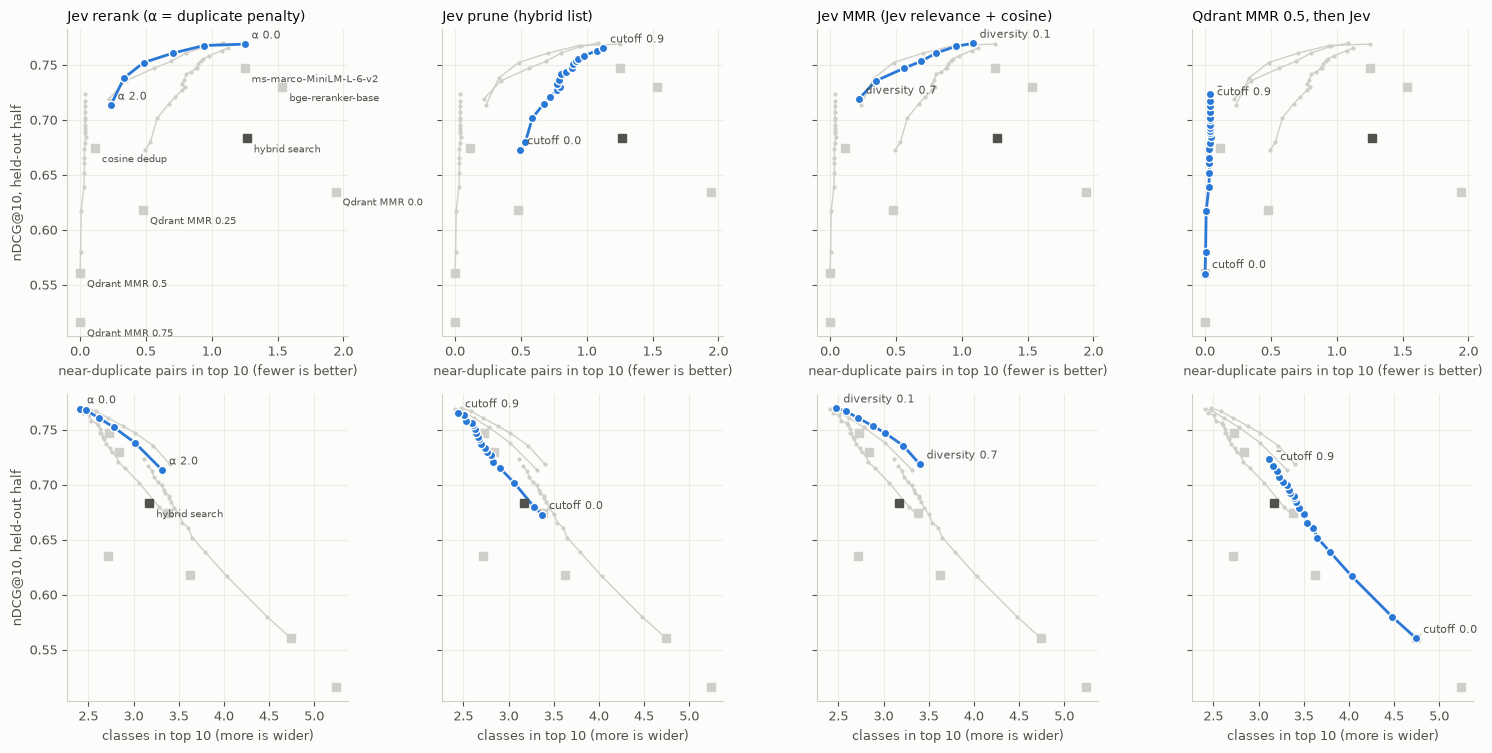

| pipeline | setting | nDCG@10 | Irrelevant | classes | near-duplicate pairs |
|---|---|---|---|---|---|
| Jev rerank | α 0.0 | 0.7689 | 38 | 2.41 | 1.25 |
| Jev rerank | α 0.1 | 0.7676 | 39 | 2.48 | 0.94 |
| Jev rerank | α 0.25 | 0.7607 | 46 | 2.62 | 0.70 |
| Jev rerank | α 0.5 | 0.7522 | 58 | 2.78 | 0.48 |
| Jev rerank | α 1.0 | 0.7381 | 70 | 3.02 | 0.33 |
| Jev rerank | α 2.0 | 0.7133 | 83 | 3.32 | 0.23 |
| Jev prune | cutoff 0.0 | 0.6728 | 103 | 3.37 | 0.50 |
| Jev prune | cutoff 0.05 | 0.6797 | 99 | 3.28 | 0.53 |
| Jev prune | cutoff 0.1 | 0.7018 | 80 | 3.06 | 0.59 |
| Jev prune | cutoff 0.15 | 0.7148 | 70 | 2.91 | 0.68 |
| Jev prune | cutoff 0.2 | 0.7205 | 61 | 2.83 | 0.72 |
| Jev prune | cutoff 0.25 | 0.7268 | 55 | 2.80 | 0.77 |
| Jev prune | cutoff 0.3 | 0.7296 | 53 | 2.76 | 0.80 |
| Jev prune | cutoff 0.35 | 0.7330 | 48 | 2.74 | 0.78 |
| Jev prune | cutoff 0.4 | 0.7367 | 46 | 2.70 | 0.79 |
| Jev prune | cutoff 0.45 | 0.7420 | 45 | 2.67 | 0.81 |
| Jev prune | cutoff 0.5 | 0.7435 | 44 | 2.67 | 0.85 |
| Jev prune | cutoff 0.55 | 0.7469 | 43 | 2.63 | 0.88 |
| Jev prune | cutoff 0.6 | 0.7475 | 43 | 2.64 | 0.89 |
| Jev prune | cutoff 0.65 | 0.7511 | 42 | 2.63 | 0.90 |
| Jev prune | cutoff 0.7 | 0.7540 | 42 | 2.60 | 0.92 |
| Jev prune | cutoff 0.75 | 0.7558 | 43 | 2.59 | 0.94 |
| Jev prune | cutoff 0.8 | 0.7581 | 42 | 2.53 | 0.98 |
| Jev prune | cutoff 0.85 | 0.7630 | 40 | 2.50 | 1.07 |
| Jev prune | cutoff 0.9 | 0.7653 | 40 | 2.44 | 1.12 |
| Jev MMR | diversity 0.1 | 0.7697 | 36 | 2.48 | 1.08 |
| Jev MMR | diversity 0.2 | 0.7668 | 43 | 2.58 | 0.95 |
| Jev MMR | diversity 0.3 | 0.7610 | 48 | 2.71 | 0.81 |
| Jev MMR | diversity 0.4 | 0.7533 | 49 | 2.88 | 0.69 |
| Jev MMR | diversity 0.5 | 0.7469 | 58 | 3.02 | 0.56 |
| Jev MMR | diversity 0.6 | 0.7354 | 72 | 3.22 | 0.35 |
| Jev MMR | diversity 0.7 | 0.7187 | 79 | 3.40 | 0.22 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.0 | 0.5602 | 139 | 4.75 | 0.00 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.05 | 0.5799 | 139 | 4.48 | 0.00 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.1 | 0.6171 | 118 | 4.03 | 0.01 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.15 | 0.6392 | 98 | 3.79 | 0.03 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.2 | 0.6519 | 91 | 3.65 | 0.03 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.25 | 0.6611 | 80 | 3.60 | 0.03 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.3 | 0.6655 | 76 | 3.54 | 0.03 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.35 | 0.6731 | 74 | 3.50 | 0.03 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.4 | 0.6792 | 69 | 3.45 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.45 | 0.6843 | 68 | 3.42 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.5 | 0.6883 | 68 | 3.39 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.55 | 0.6901 | 68 | 3.39 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.6 | 0.6922 | 67 | 3.35 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.65 | 0.6952 | 69 | 3.33 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.7 | 0.6996 | 68 | 3.31 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.75 | 0.7020 | 68 | 3.27 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.8 | 0.7069 | 69 | 3.23 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.85 | 0.7124 | 67 | 3.20 | 0.04 |
| Qdrant MMR 0.5 + Jev prune | cutoff 0.9 | 0.7174 | 67 | 3.16 | 0.04 |
| Qdrant MMR 0.5 + Jev rerank | – | 0.7233 | 66 | 3.12 | 0.04 |

In [15]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, CONTEXT, SERIES = "#fcfcfb", "#0b0b0b", "#52514e", "#cfcec8", "#2a78d6"
PANELS = [("Jev rerank (α = duplicate penalty)", ["Jev rerank"]), ("Jev prune (hybrid list)", ["Jev prune"]),
          ("Jev MMR (Jev relevance + cosine)", ["Jev MMR"]),
          (f"Qdrant MMR {MID}, then Jev", [f"Qdrant MMR {MID} + Jev prune", f"Qdrant MMR {MID} + Jev rerank"])]
AXES = [("pairs", "near-duplicate pairs in top 10 (fewer is better)"), ("classes", "classes in top 10 (more is wider)")]
plt.rcParams.update({"font.size": 9, "axes.edgecolor": CONTEXT, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})
fig, axs = plt.subplots(2, len(PANELS), figsize=(15, 7.6), sharey=True, facecolor=SURFACE)
for row, (key, xlabel) in enumerate(AXES):
    for col, (title, mine) in enumerate(PANELS):
        ax = axs[row, col]
        ax.set_facecolor(SURFACE)
        ax.grid(color="#ecebe7", linewidth=0.8)
        ax.set_axisbelow(True)
        for m, pts in test.items():
            xs, ys = [p[key] for p in pts.values()], [p["ndcg"] for p in pts.values()]
            on = m in mine
            ax.plot(xs, ys, "-o", color=SERIES if on else CONTEXT, lw=2 if on else 1, ms=6 if on else 3, zorder=3 if on else 2,
                    markeredgecolor=SURFACE, markeredgewidth=1 if on else 0)
            if on:
                names = list(pts)
                for s in {names[0], names[-1]}:
                    ax.annotate(s, (pts[s][key], pts[s]["ndcg"]), xytext=(5, 4), textcoords="offset points", color=MUTED, fontsize=8)
        for b, x in base_test.items():
            ax.plot(x[key], x["ndcg"], "s", color=MUTED if b == "hybrid search" else CONTEXT, ms=6, zorder=4 if b == "hybrid search" else 2)
            if (row, col) == (0, 0) or (b == "hybrid search" and col == 0):
                ax.annotate(b.replace("hybrid + ", "").replace(" rerank", ""), (x[key], x["ndcg"]), xytext=(5, -10),
                            textcoords="offset points", color=MUTED, fontsize=7.5)
        if row == 0:
            ax.set_title(title, color=INK, fontsize=10, loc="left")
        if col == 0:
            ax.set_ylabel("nDCG@10, held-out half")
        ax.set_xlabel(xlabel)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

rows = ["| pipeline | setting | nDCG@10 | Irrelevant | classes | near-duplicate pairs |", "|---|---|---|---|---|---|"]
rows += [f"| {m} | {s} | {x['ndcg']:.4f} | {x['irr']} | {x['classes']:.2f} | {x['pairs']:.2f} |" for m, pts in test.items() for s, x in pts.items()]
display(Markdown("\n".join(rows)))

## 9. How deep should Jev read?

Every Jev list above is the hybrid top 20. A deeper pool gives Jev more good results to promote, at one more request per 20 results. The labels bound what a deeper pool could gain before paying for one: a *label ceiling* that sorts the top k by WANDS label (Exact first, then Partial, then the rest in rank order) reaches the best nDCG@10 any reader of the top k could reach. The measured Jev rerank of the top 20 shows how much of the top-20 bound Jev already takes.

WANDS labeled what another search system retrieved, so deeper results are less often judged, and unjudged results score 0. The ceiling sees only judged results, so the bound is a lower bound on what a deep pool offers, and a real deep run would read low on nDCG for the same reason.

No Jev runs in this table: the last column is what it would cost Jev to read that pool, at 20 results per request.

In [16]:
t0 = time.time()
deep = {i: [h.id for h in wands.hybrid(client, qd[i], qs[i], limit=300, prefetch_limit=300)] for i in TEST}
ceiling = lambda pool, i: sorted(pool, key=lambda p: -gq(i).get(p, -1))[:KEEP]  # stable: ties keep rank order
rows = ["| pool | label ceiling nDCG@10 | ceiling page: classes | ceiling page: near-duplicate pairs | classes in the pool "
        "| Exact results in the pool (mean) | judged share of the pool | Jev requests per query |",
        "|---|---|---|---|---|---|---|---|"]
for k in (10, 20, 50, 100, 300):
    x = metrics({i: ceiling(deep[i][:k], i) for i in TEST}, TEST)
    pool_classes = np.mean([len({products[p]["product_class"] for p in deep[i][:k] if products[p]["product_class"]}) for i in TEST])
    ex = np.mean([sum(gq(i).get(p) == 2 for p in deep[i][:k]) for i in TEST])
    judged = np.mean([gq(i).get(p) is not None for i in TEST for p in deep[i][:k]])
    rows.append(f"| top {k} | {x['ndcg']:.4f} | {x['classes']:.2f} | {x['pairs']:.2f} | {pool_classes:.1f} | {ex:.1f} | {judged:.0%} | {-(-k // TOP)} |")
rows += ["", "Measured on the top 20, same columns:", "",
         "| pipeline | nDCG@10 | classes | near-duplicate pairs |", "|---|---|---|---|"]
for name, pg in [("hybrid search", pages["hybrid search"]), ("Jev rerank", pages["hybrid + Jev rerank"]),
                 ("Jev MMR, diversity 0.7", sweeps["Jev MMR"]["diversity 0.7"])]:
    x = metrics(pg, TEST)
    rows.append(f"| {name} | {x['ndcg']:.4f} | {x['classes']:.2f} | {x['pairs']:.2f} |")
rows += ["", f"Deep search for {len(TEST)} queries took {time.time() - t0:.0f}s."]
display(Markdown("\n".join(rows)))

| pool | label ceiling nDCG@10 | ceiling page: classes | ceiling page: near-duplicate pairs | classes in the pool | Exact results in the pool (mean) | judged share of the pool | Jev requests per query |
|---|---|---|---|---|---|---|---|
| top 10 | 0.7375 | 3.18 | 1.25 | 3.2 | 3.7 | 81% | 1 |
| top 20 | 0.8578 | 2.66 | 1.28 | 4.7 | 6.8 | 80% | 1 |
| top 50 | 0.9067 | 2.52 | 1.23 | 8.9 | 13.8 | 73% | 3 |
| top 100 | 0.9306 | 2.50 | 1.20 | 15.5 | 21.0 | 65% | 5 |
| top 300 | 0.9632 | 2.45 | 1.15 | 41.1 | 33.3 | 46% | 15 |

Measured on the top 20, same columns:

| pipeline | nDCG@10 | classes | near-duplicate pairs |
|---|---|---|---|
| hybrid search | 0.6831 | 3.17 | 1.27 |
| Jev rerank | 0.7689 | 2.41 | 1.25 |
| Jev MMR, diversity 0.7 | 0.7187 | 3.40 | 0.22 |

Deep search for 240 queries took 28s.

## 10. Jev on the top 100

Jev reads the hybrid top 100 for every query: relevance questions only, 20 results per request, numbered 1 to 20 within each request (the format the pilot checked), so 5 requests per query. From the same answers:

- **Jev rerank, top d**: sort the top d by Jev's relevance answer, for d = 20, 50, 100;
- **Jev MMR, top d**: section 8's Jev MMR over the top d, diversity swept;
- **MiniLM rerank, top d**: the stronger cross-encoder from section 5 on the same pools.

The top-20 rows use the new relevance-only requests, so comparing them with section 8 also shows whether dropping the duplicate questions changes Jev's answers. Settings are chosen on the tuning half as in section 8 and reported on the held-out half. *Judged* is the share of the page with a WANDS label: deeper picks are less often judged, and unjudged results score 0, so nDCG reads deep pools low.

In [17]:
from recipes.prune.prune import relevance

DEEP, DEPTHS = 100, (20, 50, 100)
pool = [[h.id for h in wands.hybrid(client, qd[i], qs[i], limit=DEEP)] for i in range(len(queries))]
print(f"hybrid top {DEEP} for {len(pool)} queries; its top {TOP} matches the lists above on "
      f"{np.mean([p[:TOP] == c for p, c in zip(pool, cands['hybrid'])]):.0%} of queries")

job = lambda i: relevance(jev, qtexts[i], [wands.text(products[p]) for p in pool[i]])
n_req = len(queries) * -(-DEEP // TOP)
with ThreadPoolExecutor(WORKERS) as ex:
    n0 = len(jev.usage)
    if USE_JEV:  # price a pilot batch before judging everything
        list(ex.map(job, range(PILOT)))
        new = jev.usage[n0:]
        est = float(np.mean(new)) * n_req if new else 0.0
        print(f"pilot: about ${est:.2f} for all {n_req:,} requests (uncached requests cost ${np.mean(new) if new else 0:.5f} each)")
        assert est <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD}: raise it to continue"
    t0 = time.time()
    deep_rel = list(ex.map(job, range(len(queries))))
print(f"judged {n_req:,} requests in {time.time() - t0:.0f}s"
      + (f"; spent ${sum(jev.usage[n0:]):.4f} on {len(jev.usage) - n0} uncached Jev requests" if USE_JEV else ""))

m = "Xenova/ms-marco-MiniLM-L-6-v2"
path = wands.DATA / f"rerank_{m.split('/')[-1]}_top{DEEP}_snip{SNIP}.json"
if path.exists():
    ce_deep = {int(i): s for i, s in json.loads(path.read_text()).items()}
else:
    enc = TextCrossEncoder(m)
    ce_deep = {i: [float(x) for x in enc.rerank(qtexts[i], [wands.text(products[p])[:SNIP] for p in c], batch_size=50)]
               for i, c in enumerate(pool)}
    path.write_text(json.dumps(ce_deep))

everyone = range(len(queries))
deep_sweeps = {}
for d in DEPTHS:
    deep_sweeps[f"Jev rerank, top {d}"] = {"–": {i: by_score(pool[i][:d], deep_rel[i][:d]) for i in everyone}}
    deep_sweeps[f"Jev MMR, top {d}"] = {f"diversity {x}": {i: jev_mmr(pool[i][:d], deep_rel[i][:d], x) for i in everyone}
                                        for x in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)}
    deep_sweeps[f"MiniLM rerank, top {d}"] = {"–": {i: by_score(pool[i][:d], ce_deep[i][:d]) for i in everyone}}

judged = lambda pg: np.mean([grade(i, p) is not None for i in TEST for p in pg[i]])
rows = ["| pipeline | setting | chosen on the tuning half for | nDCG@10 | change vs hybrid (95% CI) | Irrelevant | classes | near-duplicate pairs | judged |",
        "|---|---|---|---|---|---|---|---|---|"]
def add(name, setting, why, pg):
    x = metrics(pg, TEST)
    dd, lo, hi = paired_bootstrap(hyb_nd, [wands.ndcg(pg[i], gq(i)) for i in TEST])
    rows.append(f"| {name} | {setting} | {why} | {x['ndcg']:.4f} | {dd:+.4f} ({lo:+.4f} to {hi:+.4f}) | {x['irr']} "
                f"| {x['classes']:.2f} | {x['pairs']:.2f} | {judged(pg):.0%} |")
add("hybrid search", "", "baseline", pages["hybrid search"])
for name, sw in deep_sweeps.items():
    t = {s: metrics(pg, TUNE) for s, pg in sw.items()}
    acc = max(t, key=lambda s: t[s]["ndcg"])
    ok = [s for s in t if t[s]["ndcg"] >= tune_hybrid]
    div = min(ok, key=lambda s: (t[s]["pairs"], -t[s]["ndcg"])) if ok else None
    add(name, acc, "best nDCG", sw[acc])
    if div is not None and div != acc:
        add(name, div, "fewest duplicates, nDCG ≥ hybrid", sw[div])
for d in DEPTHS:
    add(f"label ceiling, top {d}", "", "upper bound, not Jev", {i: ceiling(pool[i][:d], i) for i in everyone})
display(Markdown(f"**{'Jev' if USE_JEV else 'SIMULATED Jev'}**, {len(TEST)} held-out queries\n\n" + "\n".join(rows)))

nd = lambda pg: [wands.ndcg(pg[i], gq(i)) for i in TEST]
R = lambda name, d: deep_sweeps[f"{name}, top {d}"]["–"]
rows = ["| comparison | nDCG@10 difference (95% CI) |", "|---|---|"]
for label_, a, b in [("Jev rerank: top 50 − top 20", R("Jev rerank", 20), R("Jev rerank", 50)),
                     ("Jev rerank: top 100 − top 20", R("Jev rerank", 20), R("Jev rerank", 100)),
                     ("top 100: Jev rerank − MiniLM rerank", R("MiniLM rerank", 100), R("Jev rerank", 100)),
                     ("top 20: relevance-only request − section 8 request", pages["hybrid + Jev rerank"], R("Jev rerank", 20))]:
    dd, lo, hi = paired_bootstrap(nd(a), nd(b))
    rows.append(f"| {label_} | {dd:+.4f} ({lo:+.4f} to {hi:+.4f}) |")
display(Markdown("\n".join(rows)))

hybrid top 100 for 480 queries; its top 20 matches the lists above on 100% of queries


pilot: about $0.25 for all 2,400 requests (uncached requests cost $0.00011 each)


judged 2,400 requests in 195s; spent $0.2576 on 2400 uncached Jev requests


**Jev**, 240 held-out queries

| pipeline | setting | chosen on the tuning half for | nDCG@10 | change vs hybrid (95% CI) | Irrelevant | classes | near-duplicate pairs | judged |
|---|---|---|---|---|---|---|---|---|
| hybrid search |  | baseline | 0.6831 | +0.0000 (+0.0000 to +0.0000) | 102 | 3.17 | 1.27 | 81% |
| Jev rerank, top 20 | – | best nDCG | 0.7661 | +0.0830 (+0.0664 to +0.0988) | 39 | 2.41 | 1.28 | 86% |
| Jev MMR, top 20 | diversity 0.1 | best nDCG | 0.7662 | +0.0831 (+0.0662 to +0.0992) | 39 | 2.49 | 1.12 | 86% |
| Jev MMR, top 20 | diversity 0.8 | fewest duplicates, nDCG ≥ hybrid | 0.6918 | +0.0087 (-0.0075 to +0.0247) | 94 | 3.66 | 0.11 | 81% |
| MiniLM rerank, top 20 | – | best nDCG | 0.7469 | +0.0638 (+0.0480 to +0.0800) | 83 | 2.73 | 1.25 | 85% |
| Jev rerank, top 50 | – | best nDCG | 0.7667 | +0.0836 (+0.0629 to +0.1040) | 31 | 2.30 | 1.27 | 86% |
| Jev MMR, top 50 | diversity 0.1 | best nDCG | 0.7650 | +0.0819 (+0.0621 to +0.1025) | 30 | 2.42 | 0.87 | 86% |
| Jev MMR, top 50 | diversity 0.7 | fewest duplicates, nDCG ≥ hybrid | 0.7024 | +0.0193 (-0.0021 to +0.0397) | 67 | 3.56 | 0.17 | 81% |
| MiniLM rerank, top 50 | – | best nDCG | 0.7431 | +0.0600 (+0.0419 to +0.0782) | 93 | 2.71 | 1.10 | 86% |
| Jev rerank, top 100 | – | best nDCG | 0.7578 | +0.0747 (+0.0519 to +0.0967) | 33 | 2.26 | 1.08 | 85% |
| Jev MMR, top 100 | diversity 0.1 | best nDCG | 0.7517 | +0.0686 (+0.0451 to +0.0905) | 30 | 2.34 | 0.74 | 85% |
| Jev MMR, top 100 | diversity 0.7 | fewest duplicates, nDCG ≥ hybrid | 0.6661 | -0.0171 (-0.0422 to +0.0080) | 62 | 3.67 | 0.04 | 78% |
| MiniLM rerank, top 100 | – | best nDCG | 0.7397 | +0.0566 (+0.0390 to +0.0747) | 93 | 2.71 | 1.09 | 86% |
| label ceiling, top 20 |  | upper bound, not Jev | 0.8572 | +0.1741 (+0.1529 to +0.1947) | 38 | 2.65 | 1.28 | 93% |
| label ceiling, top 50 |  | upper bound, not Jev | 0.9058 | +0.2227 (+0.1959 to +0.2492) | 17 | 2.53 | 1.22 | 96% |
| label ceiling, top 100 |  | upper bound, not Jev | 0.9287 | +0.2456 (+0.2160 to +0.2756) | 7 | 2.49 | 1.19 | 97% |

| comparison | nDCG@10 difference (95% CI) |
|---|---|
| Jev rerank: top 50 − top 20 | +0.0005 (-0.0105 to +0.0122) |
| Jev rerank: top 100 − top 20 | -0.0083 (-0.0233 to +0.0065) |
| top 100: Jev rerank − MiniLM rerank | +0.0181 (-0.0029 to +0.0376) |
| top 20: relevance-only request − section 8 request | -0.0028 (-0.0066 to +0.0008) |

## What the Jev run shows

Measured on 1 October 2026 with `typesafe/jev-1.13`, on the 240 held-out queries:

- **The relevance answer is what helps.** Sorting the hybrid top 20 by Jev's relevance answer raises nDCG@10 by +0.086 (95% CI +0.069 to +0.102) and cuts Irrelevant results in the top 10 from 102 to 38. The prune does the same thing less directly: its tuned cutoff lands at 0.9, the top of the grid, and 83% of pages are backfilled, for +0.082 and 40 Irrelevant.
- **It beats both local cross-encoders** reading the same 20 results and the same 300 characters: bge-reranker-base gains +0.047 and ms-marco-MiniLM-L-6-v2 +0.064, and both leave 83 Irrelevant results. Paired over the held-out queries, Jev's rerank beats MiniLM by +0.022 (+0.008 to +0.039) and bge-reranker-base by +0.039 (+0.023 to +0.055).
- **Time and cost.** 960 Jev requests took 172 s with 8 workers (about 86 s per 480 lists) and cost $0.164 ($0.00017 each). On a laptop CPU, after a one-off model download, bge-reranker-base scores the 480 hybrid lists in 100 s and MiniLM in 18 s. Jev's edge is accuracy, not speed.
- **The duplicate question adds little on the hybrid list.** nDCG is the same with it and without it (0.7653 vs 0.7649), and at the same number of removals it ties with cosine dedup (nDCG 0.673 vs 0.672, 3.37 vs 3.42 classes on the page). With no relevance cutoff it cuts near-duplicate pairs on the page from 1.27 to 0.50, but at the tuned cutoff most pages are backfilled and the duplicates come back (1.12).
- **MMR hurts at every setting**, even at diversity 0 (−0.048), because its relevance term is dense similarity rather than the hybrid score. Jev on MMR's list (+0.034) does worse than Jev on the hybrid list.
- **Pages get narrower on the hybrid list.** Distinct product classes in the top 10 fall from 3.17 to 2.41 under the Jev rerank: ranking by relevance concentrates the page on what the query asks for.
- **For a more varied page, run Jev on MMR's list with a lower cutoff.** With the cutoff tuned on the tuning half (0.55, the lowest whose nDCG@10 there matches hybrid search's), MMR 0.5 + Jev prune on the held-out half has 3.39 classes against 3.17 and 0.04 near-duplicate pairs per page against 1.27, with nDCG@10 +0.007 (−0.012 to +0.026) against hybrid search: no measurable loss. MMR removes the near-duplicates; Jev's relevance answer wins back the quality MMR loses (0.561 → 0.690).
- **Part of the gain is coverage.** The judged share of the top 10 rises from 81.3% to 86.5%, so some of the nDCG gain comes from replacing unjudged results, which WANDS scores as 0.

- **Which Jev method (section 8).** Jev MMR and the Jev rerank with a duplicate penalty trace the same frontier, and both beat the Jev prune at every level of repetition: the prune's backfill brings duplicates back. With settings chosen on the tuning half:
  - *best nDCG@10*: Jev MMR at diversity 0.1, 0.770 (+0.087, 95% CI +0.069 to +0.103), level with the plain rerank (0.769);
  - *more variety and better quality*: Jev MMR at diversity 0.7, +0.036 (+0.019 to +0.052) with 3.40 classes and 0.22 near-duplicate pairs per page, against hybrid's 3.17 and 1.27. At the same 3.39 classes, Qdrant MMR + Jev prune reaches only 0.690;
  - *least repetition*: Qdrant MMR 0.5 + Jev rerank, +0.040 (+0.020 to +0.061) with 0.04 near-duplicate pairs and 3.12 classes. Qdrant's MMR reads the top 50, so it has more to spread over than Jev MMR's top 20.
- **Deeper pools have headroom (section 9).** Sorting the pool by WANDS label reaches nDCG@10 0.858 on the top 20, 0.907 on the top 50, 0.931 on the top 100 and 0.963 on the top 300, with 6.8, 13.8, 21.0 and 33.3 Exact results per query. Jev's rerank takes about half of the top-20 headroom (0.683 → 0.769 of 0.858). The judged share falls from 80% at the top 20 to 46% at the top 300, so a deep run would be measured low.

- **Reading deeper does not help (section 10).** With Jev reading the hybrid top 100 (2,400 relevance-only requests, $0.258, 195 s), the rerank's nDCG@10 stays flat: top 50 − top 20 = +0.001 (−0.011 to +0.012) and top 100 − top 20 = −0.008 (−0.023 to +0.007), although the label ceiling rises from 0.857 to 0.929. Jev's pages stay 85–86% judged at every depth, so unjudged results don't explain it. Most likely Jev's answer separates relevant from irrelevant better than Exact from Partial, and a deeper pool adds Partial results that score as high as the Exact ones. Depth does cut Irrelevant results (39 → 31 at the top 50) and near-duplicates at the same nDCG (Jev MMR at diversity 0.1: 1.12 → 0.87 pairs at the top 50). MiniLM doesn't gain from depth either (0.747 → 0.740), and at the top 100 Jev's lead over it, +0.018 (−0.003 to +0.038), is no longer significant.
- **Relevance-only requests are as good and cheaper.** Sorting the top 20 by answers from relevance-only requests instead of section 8's requests (which also carry the duplicate questions) changes nDCG@10 by −0.003 (−0.007 to +0.001), at $0.00011 per request instead of $0.00017.

Three recipes hold up on this collection, all reading the hybrid top 20 with one Jev request:

- **Best page quality:** one relevance-only Jev request over the hybrid top 20 ($0.00011 per query), sort by Jev's answer (or Jev MMR at diversity 0.1), keep 10. Reading deeper costs more and does not raise nDCG.
- **More variety without losing quality:** Jev MMR at diversity 0.7.
- **Least repetition:** Qdrant MMR 0.5 over the hybrid top 50, Jev on its top 20, sort by Jev's answer.

The Jev prune is dominated by these, and the duplicate question is only useful as a penalty (Jev rerank α), not as a filter.

## Reading the results

- **Simulated or real.** If the first cell printed SIMULATED, every Jev number above comes from WANDS labels plus noise: it checks the pipeline, not Jev. Run with `OPENROUTER_API_KEY` set to measure Jev (960 requests, about $0.16).
- **nDCG and unjudged results.** WANDS scores unjudged results as 0. A prune that swaps unjudged results for judged ones raises nDCG without improving the page; the *judged in top 10* column shows how much of any gain comes from that.
- **nDCG and duplicates.** WANDS judges each variant separately, so dropping a near-duplicate of an Exact result lowers nDCG even when the page gets better. Compare dedup methods at equal nDCG loss (the sweep), not on nDCG alone.
- **The Irrelevant signal is small.** Hybrid search's top 10 is only about 4% Irrelevant on WANDS, so the Irrelevant count separates the methods on roughly a fifth of the queries.